## CAP5937: Final Project Ben Prishtina

# Tank Game Learning

In [1]:
# initialization code
import numpy as np
from keras.datasets import mnist
%matplotlib inline
from matplotlib import pyplot as plt
from scipy import stats
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
import os
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import resnet34, ResNet34_Weights

# Sets device to "cuda" if a GPU is available  (in Colabs, enable GPU by Edit->Notebook Settings-->Hardware Accelerator=GPU)
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(device) # make sure you're using GPU instance
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version used by torch:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

cuda
Torch version: 2.5.1+cu121
CUDA available: True
CUDA version used by torch: 12.1
GPU: NVIDIA GeForce RTX 2070


In [2]:
from QNetwork import QNetwork

In [3]:
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

In [4]:
from TankGame import TankGame
import numpy as np
import torch.optim as optim

env = TankGame(render_mode=False)

state_dim = len(env.reset())
action_dim = 4

q_net = QNetwork(state_dim, action_dim)
target_net = QNetwork(state_dim, action_dim)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
buffer = ReplayBuffer()

gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

pygame 2.6.1 (SDL 2.28.4, Python 3.10.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Training of the AI player

In [5]:
import random
import torch
import torch.nn as nn

episodes = 300

rewards_list = []
epsilons = []

for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    for t in range(500):  # max steps
        # ε-greedy action
        if random.random() < epsilon:
            action = random.randint(0, action_dim - 1)
        else:
            with torch.no_grad():
                q_values = q_net(torch.tensor(state, dtype=torch.float32))
                action = torch.argmax(q_values).item()

        next_state, reward, done = env.step(action)

        buffer.add(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        # Train
        if len(buffer) > batch_size:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)

            q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()

            with torch.no_grad():
                next_q = target_net(next_states).max(1)[0]
                target = rewards + gamma * next_q * (1 - dones)

            loss = nn.MSELoss()(q_values, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    # Update target network
    if episode % 10 == 0:
        target_net.load_state_dict(q_net.state_dict())

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    print(f"Episode {episode}, Reward: {total_reward:.2f}, Epsilon: {epsilon:.3f}")
    rewards_list.append(total_reward)
    epsilons.append(epsilon)

torch.save(q_net.state_dict(), "tank_dqn.pth")

Episode 0, Reward: -155.97, Epsilon: 0.995
Episode 1, Reward: -85.41, Epsilon: 0.990
HIT!
Episode 2, Reward: 10.00, Epsilon: 0.985
Episode 3, Reward: -164.66, Epsilon: 0.980
Episode 4, Reward: -141.72, Epsilon: 0.975
Episode 5, Reward: -154.11, Epsilon: 0.970
HIT!
Episode 6, Reward: -9.09, Epsilon: 0.966
Episode 7, Reward: -128.68, Epsilon: 0.961
Episode 8, Reward: -145.99, Epsilon: 0.956
Episode 9, Reward: -124.56, Epsilon: 0.951
HIT!
Episode 10, Reward: 1.31, Epsilon: 0.946
Episode 11, Reward: -211.91, Epsilon: 0.942
Episode 12, Reward: -116.86, Epsilon: 0.937
Episode 13, Reward: -121.17, Epsilon: 0.932
Episode 14, Reward: -150.07, Epsilon: 0.928
HIT!
Episode 15, Reward: -50.79, Epsilon: 0.923
HIT!
Episode 16, Reward: -4.32, Epsilon: 0.918
HIT!
Episode 17, Reward: 6.25, Epsilon: 0.914
Episode 18, Reward: -55.35, Epsilon: 0.909
Episode 19, Reward: -188.41, Epsilon: 0.905
Episode 20, Reward: -50.74, Epsilon: 0.900
Episode 21, Reward: -74.53, Epsilon: 0.896
Episode 22, Reward: -128.18, 

# Graph Training Results

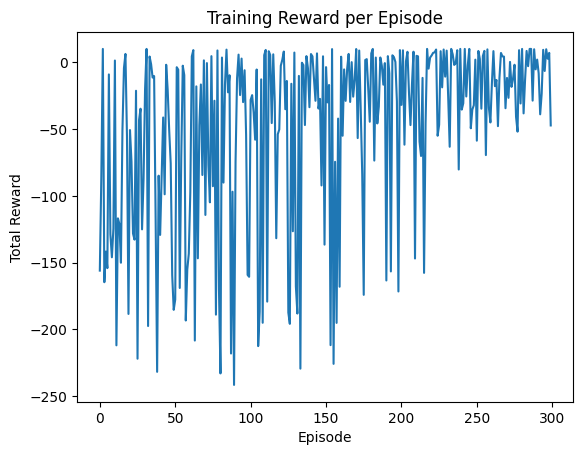

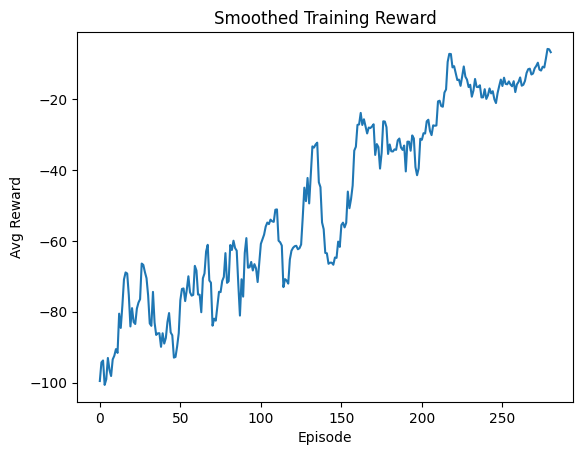

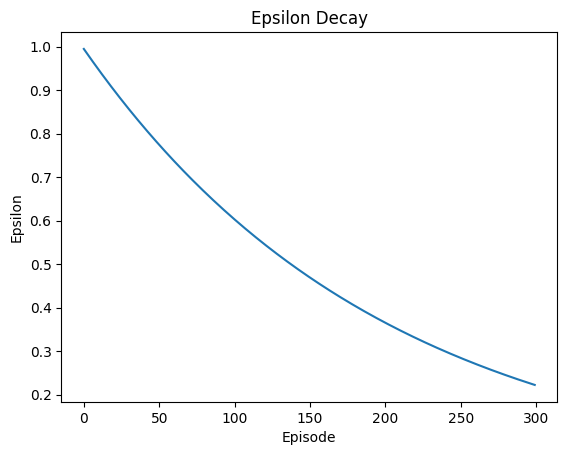

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(rewards_list)
plt.title("Training Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

window = 20
smoothed = np.convolve(rewards_list, np.ones(window)/window, mode='valid')

plt.plot(smoothed)
plt.title("Smoothed Training Reward")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.show()

plt.plot(epsilons)
plt.title("Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

## PRINT

In [7]:
import os
from nbconvert import PDFExporter
import nbformat

NOTEBOOK_NAME = "TankGameTraining.ipynb"
NOTEBOOK_PATH = NOTEBOOK_NAME

# Read the notebook as UTF-8
with open(NOTEBOOK_PATH, encoding="utf-8") as f:
    nb_node = nbformat.read(f, as_version=4)

pdf_exporter = PDFExporter()
pdf_data, resources = pdf_exporter.from_notebook_node(nb_node)

NOTEBOOK_PDF = NOTEBOOK_PATH.rsplit('.', 1)[0] + '.pdf'
with open(NOTEBOOK_PDF, 'wb') as f:
    f.write(pdf_data)

print(f"PDF CREATED: {NOTEBOOK_PDF}")

PDF CREATED: TankGameTraining.pdf
